<a href="https://colab.research.google.com/github/APES-M-JeissonS-JuanB/Sesion_4_Regresion_lineal_simple_y_Analisis_de_varianza/blob/main/Sesi%C3%B3n_4__Regresion_lineal_simple_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4. Regresión lineal simple

### Introducción
La regresión lineal simple es una técnica estadística utilizada para modelar la relación entre una variable independiente y una variable dependiente. Su principal propósito en el análisis de datos es predecir una variable a partir de otra, y entender la relación entre las dos.

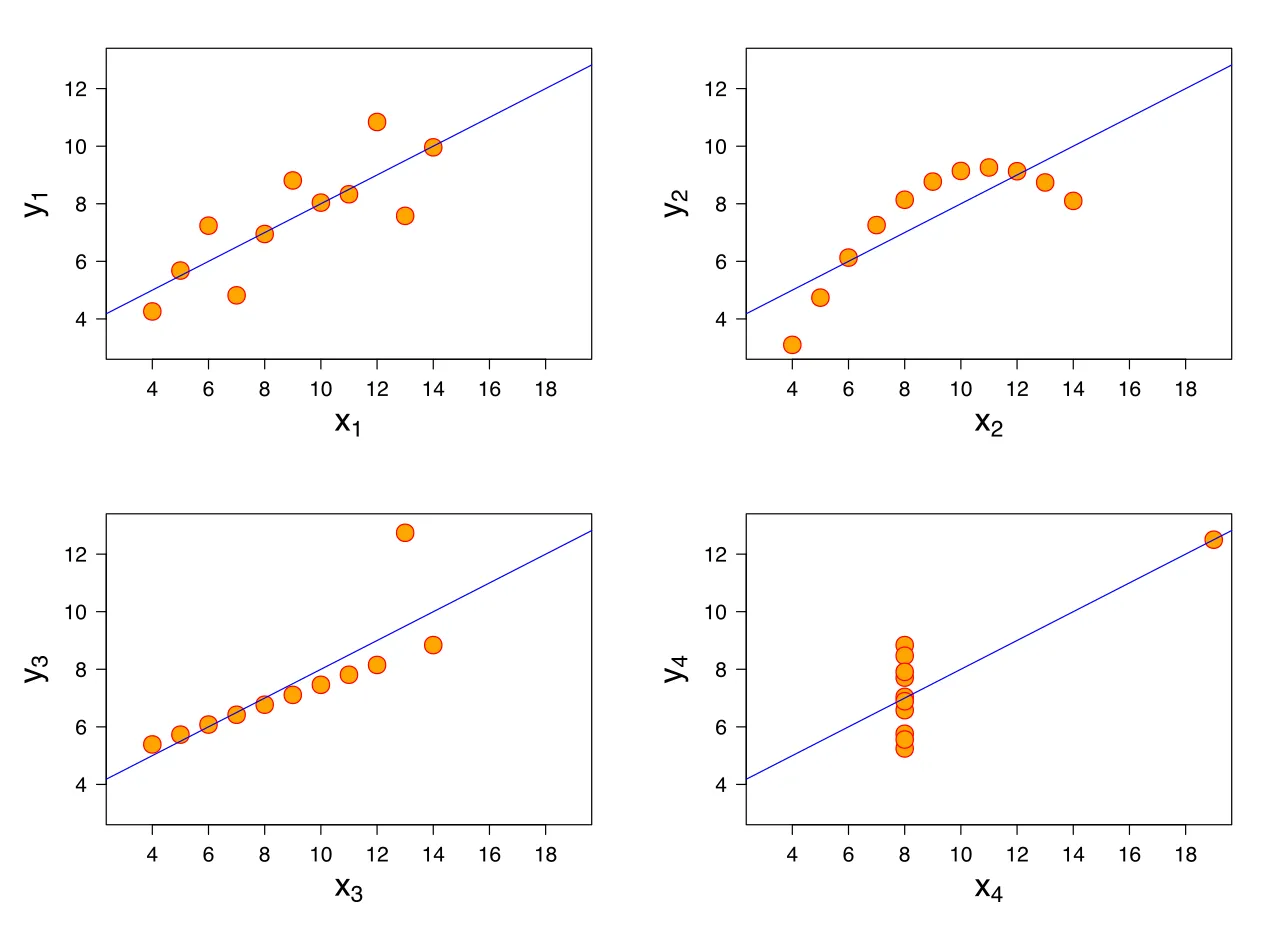

## 4.1 El problema de la regresión lineal simple

El objetivo de un modelo de regresión es tratar de explicar la relación que existe entre una variable dependiente (variable respuesta) $Y$ y un conjunto de variables independientes (variables
explicativas) $X_1,..., X_n$.

En un modelo de regresión lineal simple tratamos de explicar la relación que existe entre la variable respuesta $Y$ y una única variable explicativa $X$.

El modelo de regresión lineal simple tiene la siguiente expresión:

$$ Y = \alpha + \beta X + \epsilon $$

donde:

*   $Y$ es la variable dependiente.
*   $X$ es la variable independiente.
*   $\alpha$ es el intercepto.
*   $\beta$ es la pendiente.
*   $\epsilon$ es el error aleatorio.

Intercepto: [3.22215108]
Pendiente: [[3.96846751]]


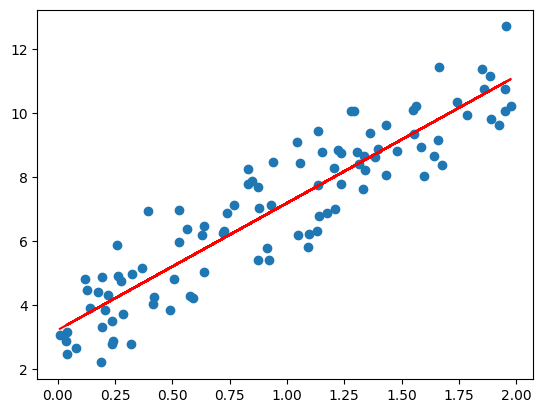

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generar datos simulados
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 3 + 4 * X + np.random.randn(100, 1)

# Crear el modelo de regresión lineal
model = LinearRegression()

# Entrenar el modelo
model.fit(X, y)

# Parámetros estimados
print(f"Intercepto: {model.intercept_}")
print(f"Pendiente: {model.coef_}")

# Graficar
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')
plt.show()

## 4.2 Estimación de parámetros

Para hacer una estimación del modelo de regresión lineal simple, trataremos de buscar una recta de la forma:

$$\hat Y = \hat \alpha + \hat\beta X = a + bX$$

de modo que se ajuste a la nube de puntos.

Para esto utilizaremos el método de mínimos cuadrados. Este método consiste en minimizarla suma de los cuadrados de los errores:

$$ \sum_{i=1}^n \epsilon_i^2=\sum_{i=1}^n(y_i-\hat y_i)^2 $$

Es decir, la suma de los cuadrados de las diferencias entre los valores reales observados ($y_i$) y los valores estimados ($\hat y_i$).

Con este método, las expresiones que se obtiene para $a$ y $b$ son las siguientes:

$$ a=\bar y-b\bar x$$
donde
$$b=\frac{S_{XY}}{S^2_X}$$

y $\bar x$, $\bar y$ denotan las medias muestrales de $X$ e $Y$ (respectivamente), $S^2_X$ es la varianza muestral de $X$ y $S_{XY}$ es la covarianza muestral entre $X$ e $Y$.

Usualmente la cantidad b se denomina coeficiente de regresión de Y sobre X.

## 4.3 El coeficiente de regresión

El coeficiente de regresión nos da información sobre el comportamiento de la variable Y frente a la variable X, de manera que:

1.   Si $b = 0$ , para cualquier valor de $X$ la variable $Y$ es constante (es decir, no cambia).
2.   Si $b > 0$, esto nos indica que al aumentar el valor de $X$, también aumenta el valor de $Y$.
3.   Si $b < 0$, esto nos indica que al aumentar el valor de $X$, el valor de $Y$ disminuye.

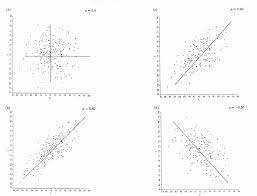

## 4.4 Coeficiente de determinación

La variabilidad del modelo, se puede descomponer como:

$$\sum(y_i-\bar y)^2=\sum(\hat y_i-\bar y)^2+\sum(y_i-\hat y_i)^2$$

o también:

$$SCT = SCreg + SCres$$

Así, se puede definir el coeficiente de determinación como:

$$r^2= \frac{\sum(\hat y_i-\bar y)^2}{\sum(y_i-\bar y)^2}=\frac{SCreg}{SCT}$$

El coeficiente de determinación puede interpretarse como la proporción de variabilidad de $Y$ que es explicada por $X$. Mide la proximidad de la recta ajustada a los valores observados de $Y$.

## 4.5 Contraste de regresión

En el contraste de regresión contrastamos la hipótesis nula de que la pendiente de la recta es cero, es decir, que no existe relación o dependencia lineal entre las dos variables.

$$H_0:\beta=0$$
$$H_1: \beta\neq 0$$

En la tabla ANOVA del análisis de regresión el estadístico F nos permite realizar dicho contraste.

¿Qué se concluye si se rechaza la hipótesis nula?

## 4.6 Ejemplo

Utilizando el modelo de regresión lineal, predeciremos la relación entre los dos factores/variables. La variable que estamos esperando se llama la variable dependiente.

El modelo de regresión lineal es de dos tipos:

*   Regresión lineal simple: Contiene solo una variable independiente, que utilizamos para predecir la variable dependiente usando una sola línea recta.
*   Regresión lineal múltiple: Incluye más de una variable independiente.

### Construyendo un modelo de regresión lineal
Para construir un modelo de regresión lineal en Python, seguiremos cinco pasos:

1.   Lectura y comprensión de los datos
2.   Visualización de los datos
3.   Realización de la regresión lineal simple
4.   Análisis de residuos
5.   Predicciones en el conjunto de prueba

### Lectura y comprensión de los datos
En este paso, primero importaremos las bibliotecas necesarias para importar los datos. Después de eso, realizaremos algunos comandos básicos para entender la estructura de los datos.

Podemos descargar el conjunto de datos de muestra, que estaremos utilizando en este artículo, desde [aquí.](https://github.com/Kaushik-Varma/linear_regression_model_python/blob/main/Company_data.csv)


Supongamos que tenemos datos de una empresa, donde se muestra la cantidad gastada en diferentes tipos de publicidad y sus ventas subsiguientes.

###Importar bibliotecas
Importaremos las bibliotecas numpy y pandas en el cuaderno Jupyter y leeremos los datos utilizando pandas.

In [13]:
# Conectar con mi google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Importing naumpy and pandas libraries to read the data

# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Importar librerias
import numpy as np
import pandas as pd

# Ruta archivo csv
ruta_archivo = "/content/drive/MyDrive/Notebooks/Company_data.csv"

# Leer el archivo CSV en un DataFrame de pandas
advertising = pd.read_csv(ruta_archivo)
advertising.sample(10)

,TV,Radio,Newspaper,Sales
71,109.8,14.3,31.7,12.4
77,120.5,28.5,14.2,14.2
95,163.3,31.6,52.9,16.9
166,17.9,37.6,21.6,8.0
140,73.4,17.0,12.9,10.9
145,140.3,1.9,9.0,10.3
11,214.7,24.0,4.0,17.4
16,67.8,36.6,114.0,12.5
197,177.0,9.3,6.4,14.8
160,172.5,18.1,30.7,16.4


In [15]:
# Dimensiones del dataset
advertising.shape

# Info del dataset
advertising.info()

# Describir el dataset
advertising.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


### Visualización de los datos
Ahora visualicemos los datos utilizando las bibliotecas matplotlib y seaborn. Haremos un "pairplot" (gráfico de pares) de todas las columnas para ver cuáles están más correlacionadas con las ventas.

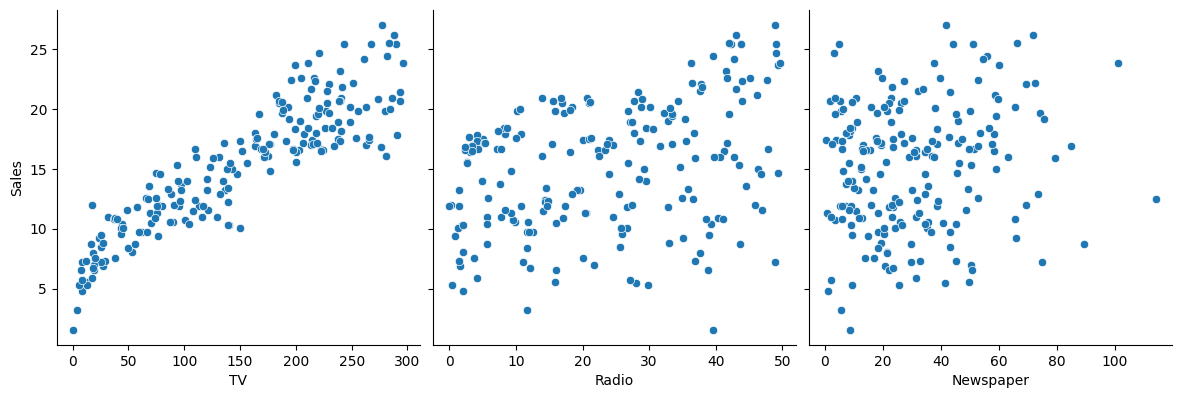

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using pairplot we'll visualize the data for correlation
sns.pairplot(advertising, x_vars=['TV', 'Radio','Newspaper'],
             y_vars='Sales', size=4, aspect=1, kind='scatter')
plt.show()

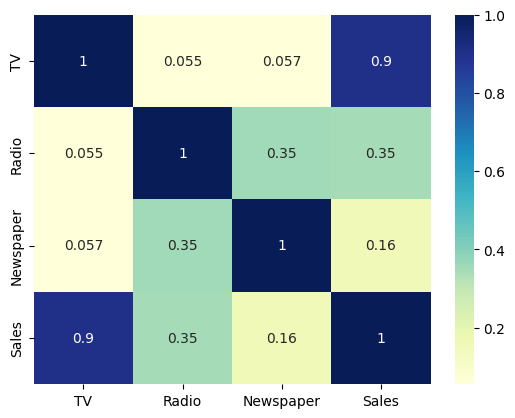

In [17]:
# Visualizing the data using heatmap
sns.heatmap(advertising.corr(), cmap="YlGnBu", annot = True)
plt.show()

Como podemos ver en los gráficos anteriores, la columna "TV" parece estar más correlacionada con las ventas.

Realicemos el modelo de regresión lineal simple utilizando "TV" como nuestra variable característica.

Realizaremos la regresión lineal simple en cuatro pasos.

1.   Crear X e y
2.   Crear los conjuntos de entrenamiento y prueba
3.   Entrenar el modelo
4.   Evaluar el modelo

Primero, asignaremos nuestra variable característica/columna "TV" como X y nuestra variable objetivo "Ventas" como y.

Para generalizar,

La variable independiente se representa con $X$, e $Y$ representa la variable objetivo en un modelo de regresión lineal simple.

In [18]:
# Creating X and y
X = advertising['TV']
y = advertising['Sales']

### Crear conjuntos de Entrenamiento y Prueba
Necesitamos dividir nuestras variables en conjuntos de entrenamiento y prueba. Utilizando el conjunto de entrenamiento, construiremos el modelo y realizaremos el modelo en el conjunto de prueba. Dividiremos los conjuntos de entrenamiento y prueba en una proporción de 70:30, respectivamente.

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7,
                                                    test_size = 0.3, random_state = 100)

In [20]:
X_train

,TV
74,213.4
3,151.5
185,205.0
26,142.9
90,134.3
...,...
87,110.7
103,187.9
67,139.3
24,62.3


In [21]:
y_train

,Sales
74,17.0
3,16.5
185,22.6
26,15.0
90,14.0
...,...
87,16.0
103,19.7
67,13.4
24,9.7


### Construcción y entrenamiento del modelo
Podemos construir un modelo de regresión lineal simple utilizando los siguientes dos paquetes:

1.   statsmodel
2.   sklearn

Primero, construiremos el modelo utilizando el paquete statsmodel. Para hacerlo, necesitamos importar la biblioteca statsmodel.api para realizar la regresión lineal.

Por defecto, la biblioteca statsmodel ajusta una línea que pasa por el origen. Pero si observamos la ecuación de regresión lineal simple $y=c+mX$, tiene un valor de intersección representado como $c$. Por lo tanto, para tener una intersección, necesitamos agregar el atributo add_constant manualmente.

In [22]:
import statsmodels.api as sm

# Adding a constant to get an intercept
X_train_sm = sm.add_constant(X_train)

Una vez que hayamos agregado la constante, podemos ajustar la línea de regresión utilizando el método OLS (Mínimos Cuadrados Ordinarios) presente en statsmodels. Después de eso, veremos los parámetros, es decir, $c$ y $m$ de la línea recta.

In [23]:
lr = sm.OLS(y_train, X_train_sm).fit()

# Printing the parameters
lr.params

,0
const,6.948683
TV,0.054546


In [24]:
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     611.2
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           1.52e-52
Time:                        02:11:54   Log-Likelihood:                -321.12
No. Observations:                 140   AIC:                             646.2
Df Residuals:                     138   BIC:                             652.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9487      0.385     18.068      0.000       6.188       7.709
TV             0.0545      0.002     24.722      0.000       0.050       0.059
==============================================================================
Omnibus:                        0.027   Durbin-Watson:                   2.196
Prob(Omnibus):                  0.987   Jarque-Bera (JB):                0.150
Skew:                          -0.006   Prob(JB):                        0.928
Kurtosis:                       2.840   Cond. No.                         328.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Se puede pensar que la recta que mejor representa el comportamiento de estas variables es:

$Sales = 6.948 + 0.054 * TV$

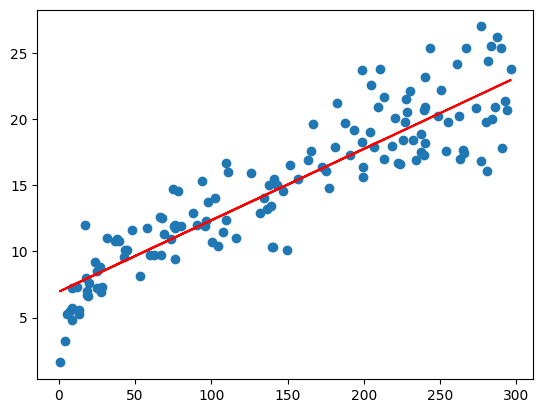

In [25]:
plt.scatter(X_train, y_train)
plt.plot(X_train, 6.948 + 0.054*X_train, 'r')
plt.show()

Análisis de Residuos
Una de las principales suposiciones del modelo de regresión lineal es que los términos de error se distribuyen de forma normal.

Error = Valor real de y - Valor predicho de y

Ahora, con el conjunto de datos tenemos que predecir el valor $y$ del conjunto de datos de entrenamiento de $X$ utilizando el atributo predict. Después de eso, crearemos los términos de error (Residuos) a partir de los datos predichos.

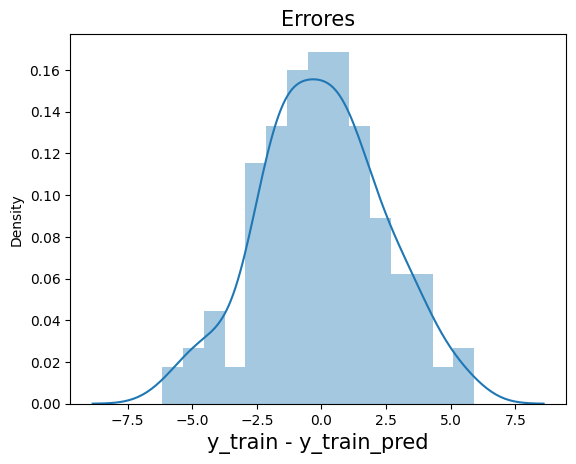

In [26]:
y_train_pred = lr.predict(X_train_sm)

# Creating residuals from the y_train data and predicted y_data
res = (y_train - y_train_pred)

fig = plt.figure()
sns.distplot(res, bins = 15)
plt.title('Errores', fontsize = 15)
plt.xlabel('y_train - y_train_pred', fontsize = 15)
plt.show()

Graficamos ahora los errores a ver si tienen algun patron definido:

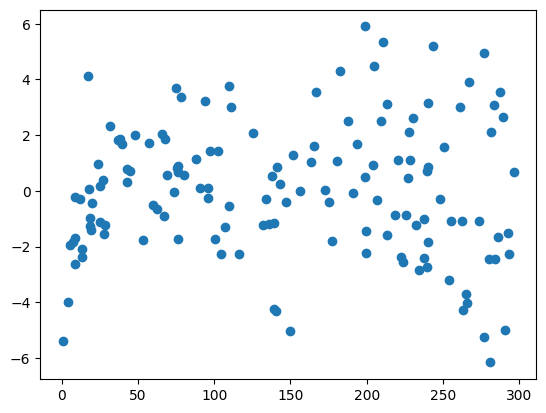

In [27]:
plt.scatter(X_train,res)
plt.show()